# 17 · Average precision per target (log scale)

For each target: the AP of No-FT and of head-FT at N = 40, 100 and 300 labels, on a **log absolute scale**, with a thin dashed line at the target's **active rate**, which is the AP a random ranking would get. The paper's reported value (orange, hollow) sits next to ours (blue; the bar is the seed mean +/- SD and the dots are the individual seeds). Targets whose pipeline has not finished show the paper's values only and fill in when this notebook is re-run.

In [1]:

from pathlib import Path
import numpy as np, pandas as pd, matplotlib as mpl, matplotlib.pyplot as plt
from IPython.display import display
BLK="#000000"; OUR="#2a78d6"; THEIR="#eb6834"; NEU="#666666"
mpl.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","savefig.facecolor":"white",
  "text.color":BLK,"axes.labelcolor":BLK,"axes.titlecolor":BLK,"xtick.color":BLK,"ytick.color":BLK,
  "axes.edgecolor":BLK,"font.size":10,"font.weight":"normal","axes.titleweight":"normal","axes.labelweight":"normal",
  "axes.grid":True,"grid.color":"#e6e6e6","axes.axisbelow":True,"axes.spines.top":False,"axes.spines.right":False})
ROOT=Path("/global/scratch/users/sergiomar10/boltzaff"); AN=ROOT/"results/analysis"
SHORT={"588689":"588689","504329":"504329","1053173-743445":"743445","493248-485317":"485317","434954-2097":"2097","540297-493091":"493091","463203-2650":"2650","624273-588549":"588549"}
ALL=list(SHORT); BUD=[40,100,300]
tc=pd.read_csv(ROOT/"BoltzFT/figures/data/trainer_control.csv"); tc["target"]=tc.target.astype(str)
P_BASE=tc[tc.arm=="base"].set_index("target"); P_FT=tc[tc.arm=="lightning"].set_index(["target","n_train"])
RATE={t:float(P_BASE.loc[t,"n_active"]/P_BASE.loc[t,"n_eval"]) for t in ALL}          # active rate = AP of a random ranking
def ours(t):
    p=AN/t/"per_seed.csv"
    if not p.exists(): return None
    d=pd.read_csv(p)
    return d if (d.arm=="headft").any() else None
OURS={t:ours(t) for t in ALL}; DONE=[t for t in ALL if OURS[t] is not None]
def rate_ours(t): d=OURS[t]; return float(d.n_active.iloc[0]/d.n_eval.iloc[0])
print("targets with our results:",[SHORT[t] for t in DONE]," | pending:",[SHORT[t] for t in ALL if t not in DONE])


targets with our results: ['588689']  | pending: ['504329', '743445', '485317', '2097', '493091', '2650', '588549']


## 1. AP per target, log absolute scale
Read a panel as: how far above the dashed chance line does each method sit, and how much does head-FT lift it. Note the very different scales: AP ranges from about 0.006 to 0.29 across targets.

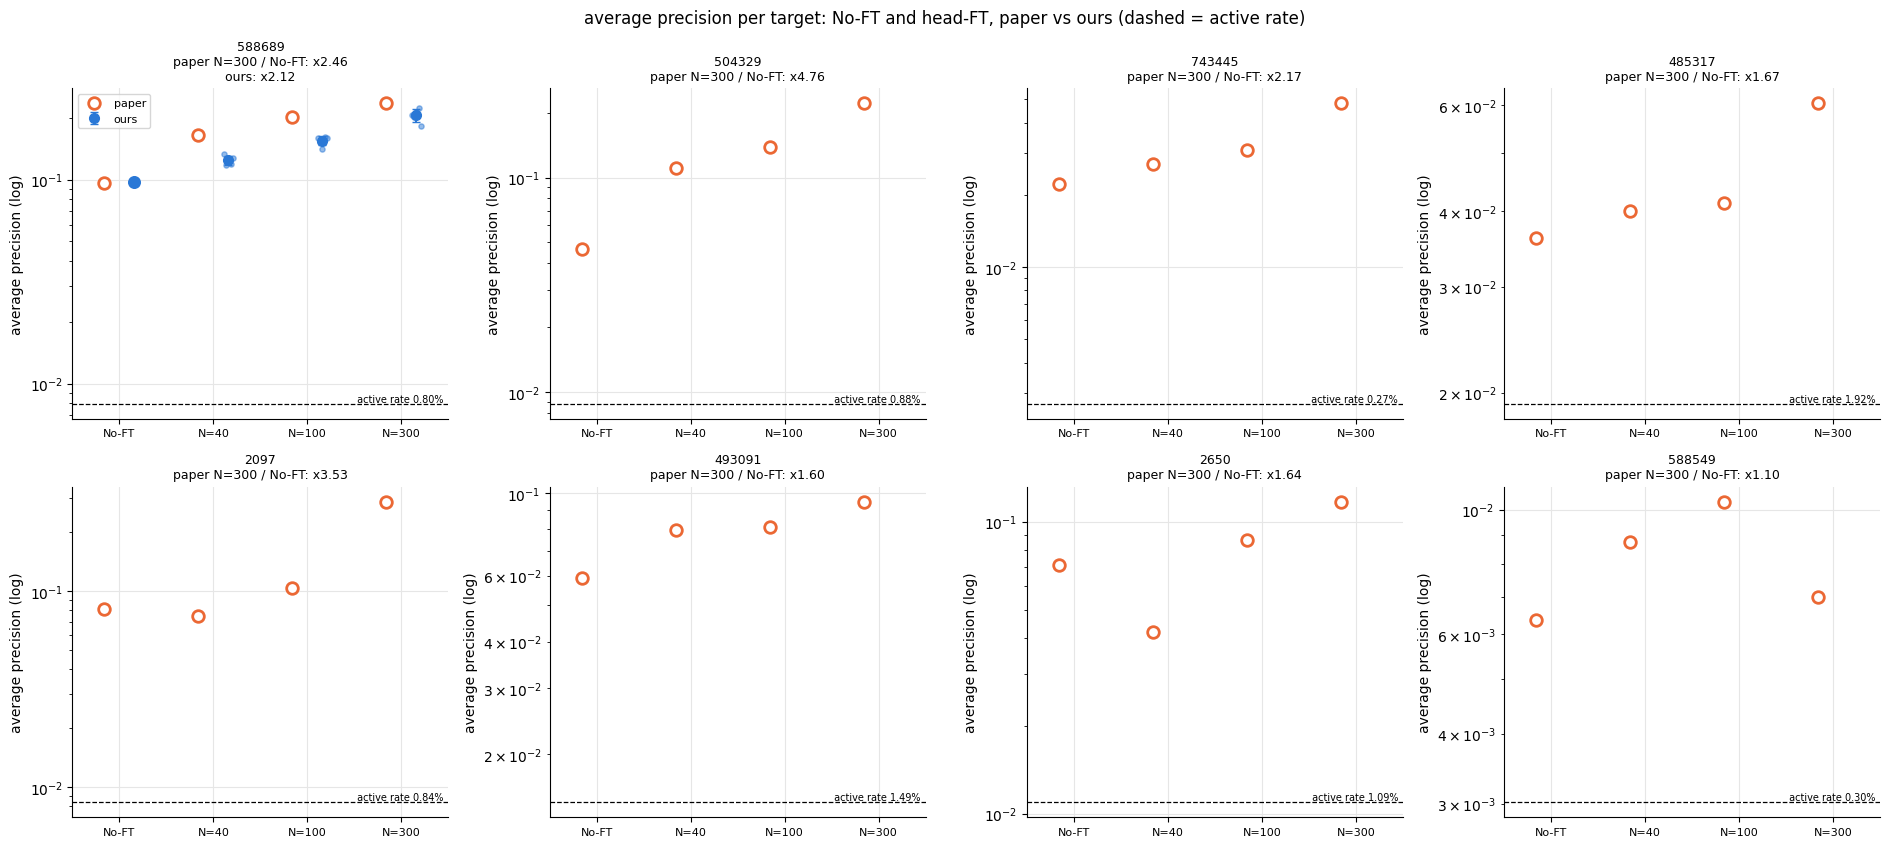

In [2]:
fig,axes=plt.subplots(2,4,figsize=(19,8.6),sharey=False)
for ax,t in zip(axes.ravel(),ALL):
    xs=np.arange(4); labs=["No-FT"]+[f"N={b}" for b in BUD]
    pv=[P_BASE.loc[t,"auprc"]]+[P_FT.loc[(t,b),"auprc"] if (t,b) in P_FT.index else np.nan for b in BUD]
    ax.scatter(xs-0.16,pv,s=70,facecolor="white",edgecolor=THEIR,lw=2,zorder=4,label="paper")
    if t in DONE:
        d=OURS[t]; b0=d[d.arm=="base"].ap.iloc[0]; means=[b0]; sds=[0.0]
        ax.scatter([0.16],[b0],s=70,color=OUR,zorder=4)
        for i,b in enumerate(BUD):
            s=d[(d.arm=="headft")&(d.n_train==b)].ap; means.append(s.mean()); sds.append(s.std(ddof=1) if len(s)>1 else 0.0)
            ax.scatter(np.full(len(s),i+1+0.16)+np.linspace(-0.05,0.05,len(s)),s,s=14,color=OUR,alpha=0.5,zorder=3)
        ax.errorbar(np.arange(4)+0.16,means,yerr=sds,fmt="o",color=OUR,ms=7,capsize=3,zorder=5,label="ours")
        r=rate_ours(t)
    else: r=RATE[t]
    ax.axhline(r,ls="--",color=BLK,lw=0.9); ax.text(3.45,r,f" active rate {100*r:.2f}%",va="bottom",ha="right",fontsize=7)
    ax.set_yscale("log"); ax.set_xticks(xs); ax.set_xticklabels(labs,fontsize=8); ax.set_xlim(-0.5,3.5)
    ratio_p=pv[3]/pv[0]; txt=f"paper N=300 / No-FT: x{ratio_p:.2f}"
    if t in DONE: txt+=f"\nours: x{means[3]/means[0]:.2f}"
    ax.set_title(f"{SHORT[t]}\n{txt}",fontsize=9); ax.set_ylabel("average precision (log)")
    if t==ALL[0]: ax.legend(fontsize=8,loc="upper left")
fig.suptitle("average precision per target: No-FT and head-FT, paper vs ours (dashed = active rate)",fontsize=12); plt.tight_layout(); plt.show()

## 2. AP as a multiple of chance
AP divided by the active rate, so targets with different base rates are comparable: 1 means no better than random.

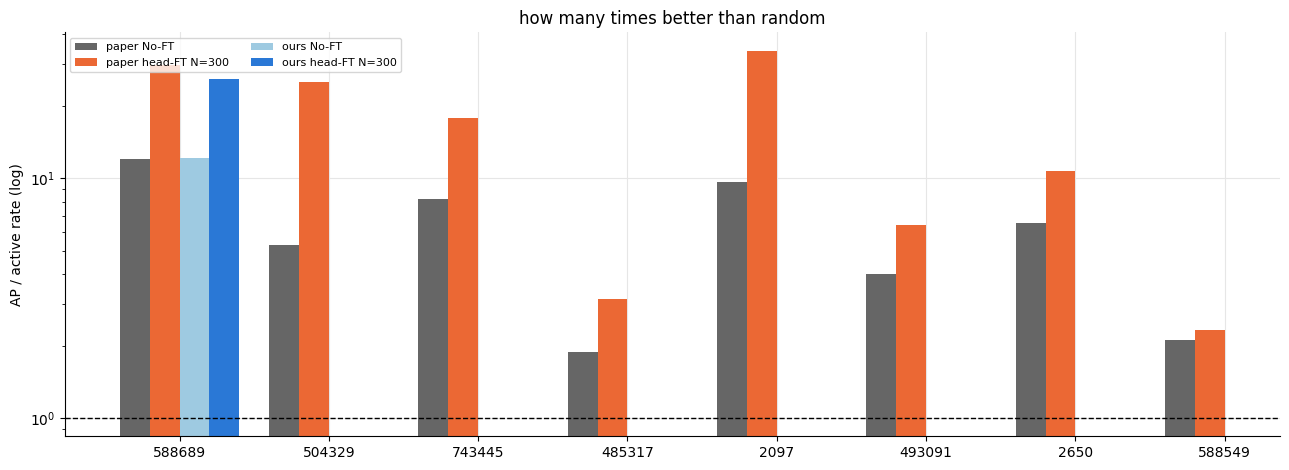

,active_rate_pct,paper_NoFT_AP,paper_N300_AP,ours_NoFT_AP,ours_N300_AP
target,,,,,
588689,0.797,0.096,0.237,0.097,0.207
504329,0.882,0.047,0.222,NaN,NaN
743445,0.270,0.022,0.048,NaN,NaN
485317,1.918,0.036,0.060,NaN,NaN
2097,0.836,0.081,0.286,NaN,NaN
493091,1.487,0.059,0.095,NaN,NaN
2650,1.093,0.071,0.117,NaN,NaN
588549,0.302,0.006,0.007,NaN,NaN


In [3]:
fig,ax=plt.subplots(figsize=(13,4.8)); x=np.arange(len(ALL)); w=0.2; rows=[]
for k,(lab,get,c) in enumerate([("paper No-FT",lambda t:(P_BASE.loc[t,"auprc"],RATE[t]),NEU),("paper head-FT N=300",lambda t:(P_FT.loc[(t,300),"auprc"],RATE[t]),THEIR)]):
    ax.bar(x+(k-1.5)*w,[get(t)[0]/get(t)[1] for t in ALL],w,color=c,label=lab)
def ob(t,arm,n=None):
    d=OURS[t]; s=d[d.arm==arm].ap if arm=="base" else d[(d.arm==arm)&(d.n_train==n)].ap; return s.mean()/rate_ours(t)
ax.bar([i+0.5*w for i,t in enumerate(ALL)],[ob(t,"base") if t in DONE else np.nan for t in ALL],w,color="#9ecae1",label="ours No-FT")
ax.bar([i+1.5*w for i,t in enumerate(ALL)],[ob(t,"headft",300) if t in DONE else np.nan for t in ALL],w,color=OUR,label="ours head-FT N=300")
ax.axhline(1,color=BLK,ls="--",lw=1); ax.set_yscale("log"); ax.set_xticks(x); ax.set_xticklabels([SHORT[t] for t in ALL]); ax.set_ylabel("AP / active rate (log)")
ax.set_title("how many times better than random"); ax.legend(fontsize=8,ncol=2); plt.tight_layout(); plt.show()
for t in ALL:
    rows.append(dict(target=SHORT[t],active_rate_pct=round(100*(rate_ours(t) if t in DONE else RATE[t]),3),paper_NoFT_AP=round(P_BASE.loc[t,"auprc"],3),paper_N300_AP=round(P_FT.loc[(t,300),"auprc"],3),
        ours_NoFT_AP=round(OURS[t][OURS[t].arm=="base"].ap.iloc[0],3) if t in DONE else np.nan,
        ours_N300_AP=round(OURS[t][(OURS[t].arm=="headft")&(OURS[t].n_train==300)].ap.mean(),3) if t in DONE else np.nan))
display(pd.DataFrame(rows).set_index("target"))

## 3. The lift from head-FT, per target
Head-FT AP divided by No-FT AP at each budget, per target. The paper's headline is the geometric mean across its eight targets (2.14x at N=300). A ratio below 1 means fine-tuning did not help that target.

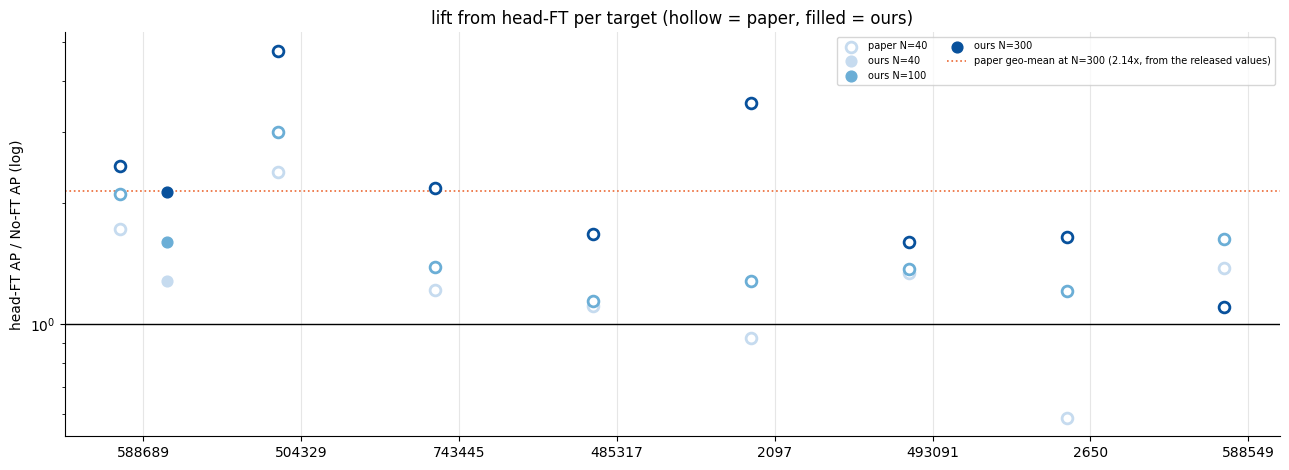

paper geo-mean AP ratio at N=300 across the 8 targets from the released per-target values: 2.14x
targets where the paper's N=300 head-FT is below No-FT: []


In [4]:
fig,ax=plt.subplots(figsize=(13,4.8)); x=np.arange(len(ALL)); cols={40:"#c6dbef",100:"#6baed6",300:"#08519c"}
for b in BUD:
    pr=[P_FT.loc[(t,b),"auprc"]/P_BASE.loc[t,"auprc"] if (t,b) in P_FT.index else np.nan for t in ALL]
    ax.scatter(x-0.15,pr,s=60,facecolor="white",edgecolor=cols[b],lw=2,label=f"paper N={b}" if b==40 else None,zorder=3)
    ax.scatter(x+0.15,[OURS[t][(OURS[t].arm=="headft")&(OURS[t].n_train==b)].ap.mean()/OURS[t][OURS[t].arm=="base"].ap.iloc[0] if t in DONE else np.nan for t in ALL],s=60,color=cols[b],label=f"ours N={b}",zorder=4)
geo=np.exp(np.mean([np.log(P_FT.loc[(t,300),"auprc"]/P_BASE.loc[t,"auprc"]) for t in ALL]))
ax.axhline(1,color=BLK,lw=1); ax.axhline(geo,color=THEIR,ls=":",lw=1.2,label=f"paper geo-mean at N=300 ({geo:.2f}x, from the released values)")
ax.set_yscale("log"); ax.set_xticks(x); ax.set_xticklabels([SHORT[t] for t in ALL]); ax.set_ylabel("head-FT AP / No-FT AP (log)"); ax.legend(fontsize=7,ncol=2)
ax.set_title("lift from head-FT per target (hollow = paper, filled = ours)"); plt.tight_layout(); plt.show()
print(f"paper geo-mean AP ratio at N=300 across the 8 targets from the released per-target values: {geo:.2f}x")
print("targets where the paper's N=300 head-FT is below No-FT:",[SHORT[t] for t in ALL if P_FT.loc[(t,300),"auprc"]<P_BASE.loc[t,"auprc"]])

## Reading the figures

- **The paper's own numbers.** At N=300 head-FT improves AP over No-FT on all eight targets, by factors from 1.10 (588549) to 4.76 (504329); the geometric mean computed from the released per-target values is 2.14, the paper's headline. The lift is not monotonic in the budget everywhere: at N=40 the paper's head-FT is below No-FT for 2097 and 2650, and 588549 peaks at N=100.
- **Ours.** Only 588689 is complete: No-FT AP 0.097 (paper 0.096) and head-FT at N=300 a factor of 2.12 above No-FT (paper 2.46 for this target). The other seven fill in when the notebook is re-run after their pipelines finish.
- **Scale.** AP runs from about 0.006 to 0.29, and the active rates range from 0.27% to 1.92%, which is why the panels use a log scale and separate axes; the dashed line in each panel is the AP a random ranking would get.